# Prognose av NOK/USD fra oljefuturesenes terminstruktur

Denne notebooken er et **lesbart narrativ** oppå den modulære koden i `src/`.
Hvert analysesteg kaller en `src`-modul (som også kan kjøres frittstående fra
terminalen), og forklarer hva og hvorfor underveis.

**Datakilde:** lokale Datastream/Refinitiv-uttrekk – ekte ICE Brent terminstruktur
`TRc1`–`TRc12` (full 1–12 mnd kurve) og NOK/USD, månedlig 2001–2021.

**Mål:** teste om terminstrukturens *form* (komprimert til Diebold-Li-faktorene
nivå/helning/krumning) kan forutsi kronen bedre enn en naiv random walk.

In [1]:
import sys
from pathlib import Path

# Gjør src/ importerbar uansett om notebooken kjøres fra rot eller notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from IPython.display import Image, display
import pandas as pd
from src import config

def show(*names):
    for n in names:
        display(Image(filename=str(config.OUTPUT_DIR / n)))

## Steg 1 – Datainnhenting og align

Vi leser NOK/USD og Brent-terminstrukturen gjennom det modulære
`data_loader`-grensesnittet og aligner dem på en felles månedlig datoindeks.
`M1` (front-month) er "first nearby". Resultatet er 243 komplette måneder uten
hull.

In [2]:
from src.data_acquisition import build_dataset
df = build_dataset()
df.head()

[data] Terminstruktur-kilde: Excel: ICE Brent TRc1-TRc12 (ekte, full 1-12 kurve, månedlig)
[data] FX: NOKUSD  (2001-01-31 -> 2021-03-31)
[data] Maturities: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12']
[data] 243 måneder før align -> 243 komplette måneder (2001-01-31 -> 2021-03-31)
[data] Lagret til C:\Users\jonas\Desktop\CCfolder\currency_forecasting\data\dataset.parquet


,NOKUSD,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
date,,,,,,,,,,,,,
2001-01-31,0.114055,26.66,25.71,25.46,25.22,25.00,24.77,24.53,24.30,24.09,23.89,23.60,23.35
2001-02-28,0.112199,25.57,25.71,25.71,25.53,25.31,25.11,24.91,24.71,24.49,24.15,23.91,23.61
2001-03-31,0.109105,24.74,24.92,24.85,24.74,24.60,24.45,24.30,24.13,23.89,23.69,23.49,23.25
2001-04-30,0.110216,27.89,27.66,27.28,27.01,26.73,26.44,26.13,25.82,25.52,25.22,24.92,24.62
2001-05-31,0.106720,29.34,28.00,27.53,27.23,26.93,26.60,26.24,25.92,25.59,25.26,24.95,24.69


## Steg 2 – Eksplorativ analyse

Tre spørsmål før vi modellerer: (1) Henger kronen og oljen sammen? (2) Er
sammenhengen stabil? (3) Hvordan ser terminstrukturen ut?

Vi regner korrelasjon på **månedlige endringer** (ikke nivåer), siden to trendende
nivåserier lett gir kunstig høy korrelasjon.

[eda] 243 månedlige observasjoner (2001-01-31 -> 2021-03-31)
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_nokusd_vs_frontmonth.png
[eda] Korrelasjon (avkastning) NOK/USD vs Brent M1: 0.532


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_rolling_corr_60m.png
[eda] Rullende korr: snitt 0.54, min 0.06, max 0.72
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_term_structure_3d.png


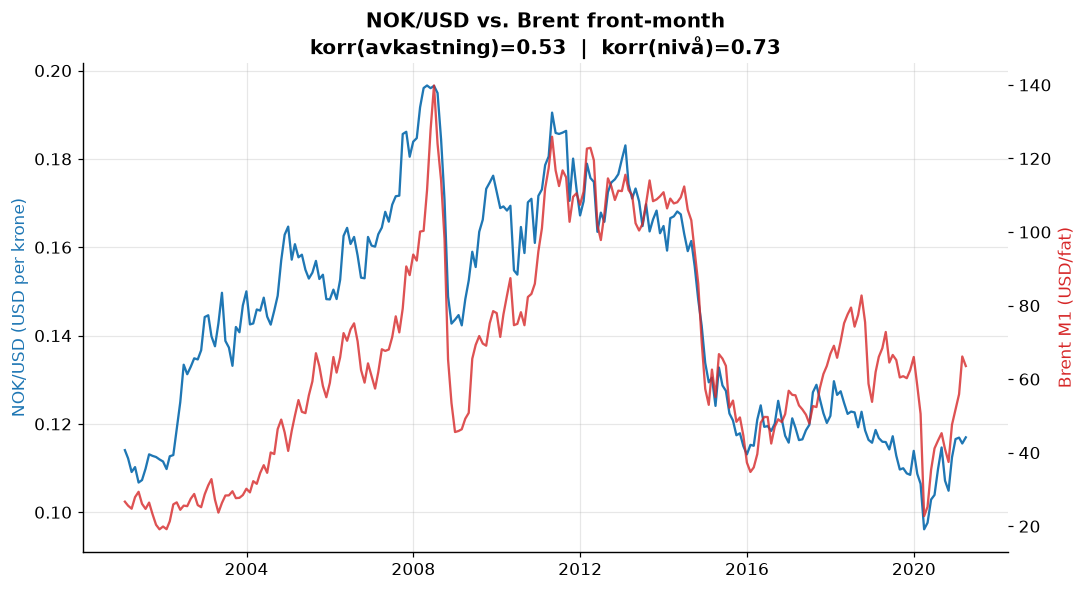

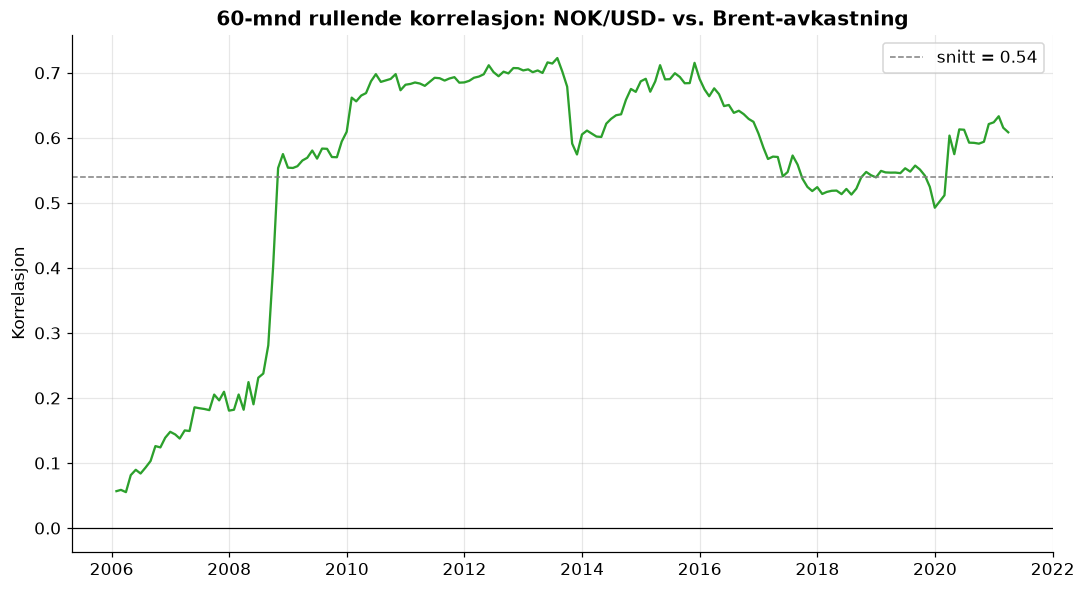

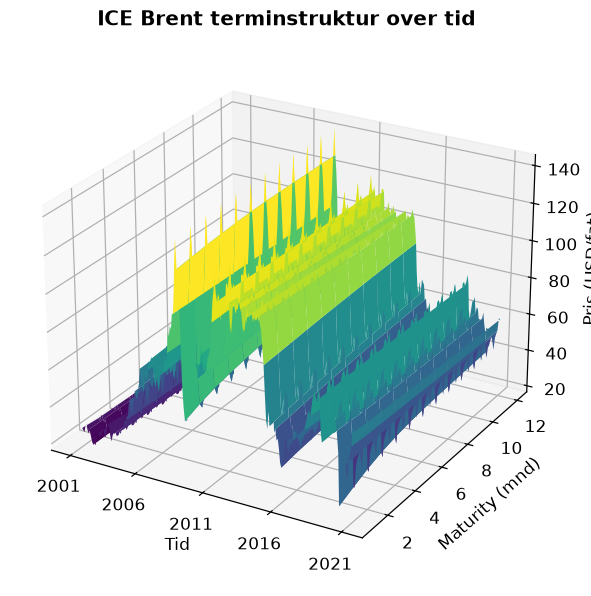

In [3]:
from src import eda
eda.run()
show("02_nokusd_vs_frontmonth.png", "02_rolling_corr_60m.png", "02_term_structure_3d.png")

## Steg 3 – Diebold-Li-faktorer

Vi komprimerer hele kurven til tre tolkbare tall per måned:

$$ y(\tau) = \beta_1 + \beta_2\frac{1-e^{-\lambda\tau}}{\lambda\tau} + \beta_3\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}-e^{-\lambda\tau}\right) $$

* **Nivå** ($\beta_1$): hele kurven opp/ned (≈ oljeprisnivået).
* **Helning** ($\beta_2$): kort vs. lang ende (contango/backwardation).
* **Krumning** ($\beta_3$): pukkel på midten.

$\lambda$ velges ved rutenett-søk som minimerer tilpasningsfeil; toppen på
krumnings-loadingen havner da midt på vårt 1–12-måneders vindu.

[dl] Valgt λ = 0.23  ->  krumningstopp ≈ 7.8 mnd
[dl] Gj.snittlig tilpasnings-RMSE: 0.085 USD/fat (snittpris ~66)


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_factor_loadings.png


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_dl_factors.png


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_sample_fit.png
[dl] Lagret faktorer til C:\Users\jonas\Desktop\CCfolder\currency_forecasting\data\factors.parquet
[dl] korr(Level, M1) = 0.950


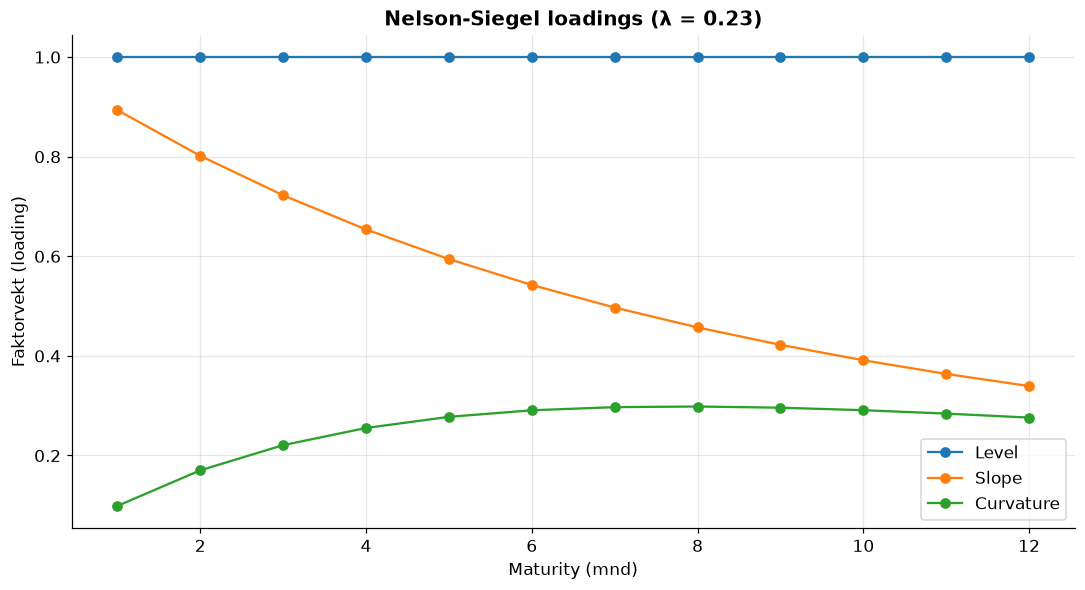

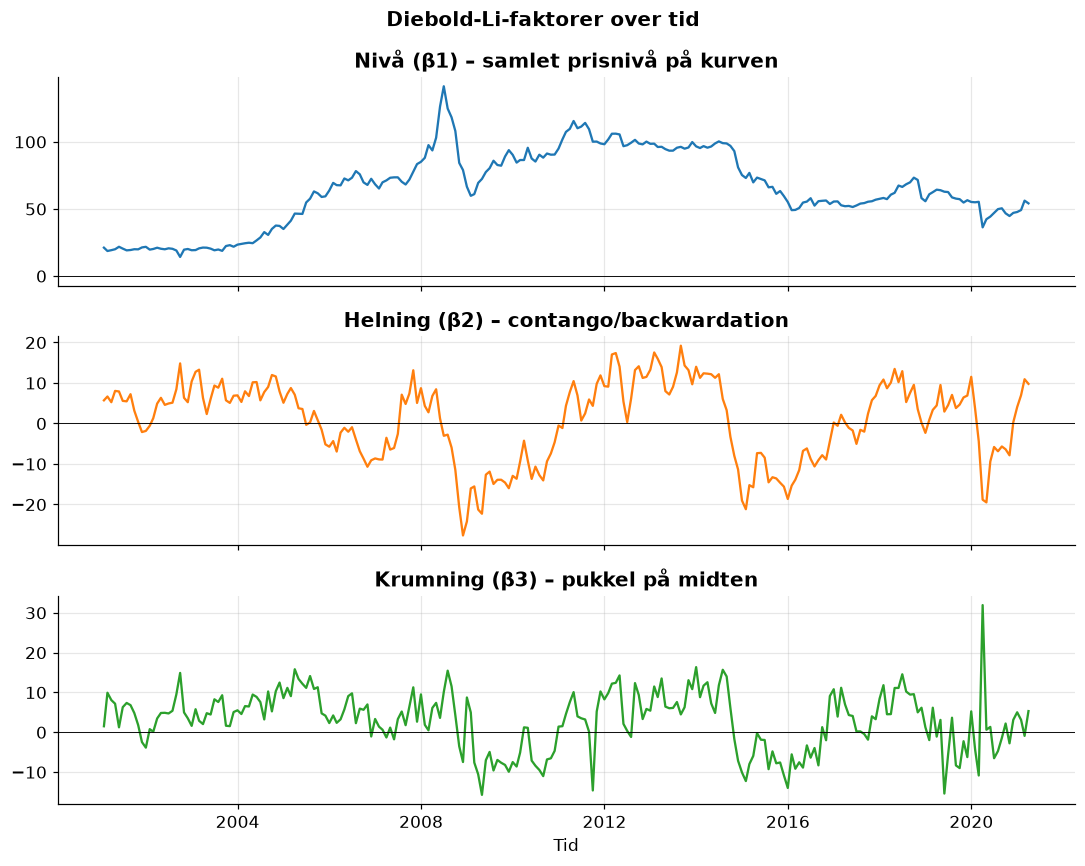

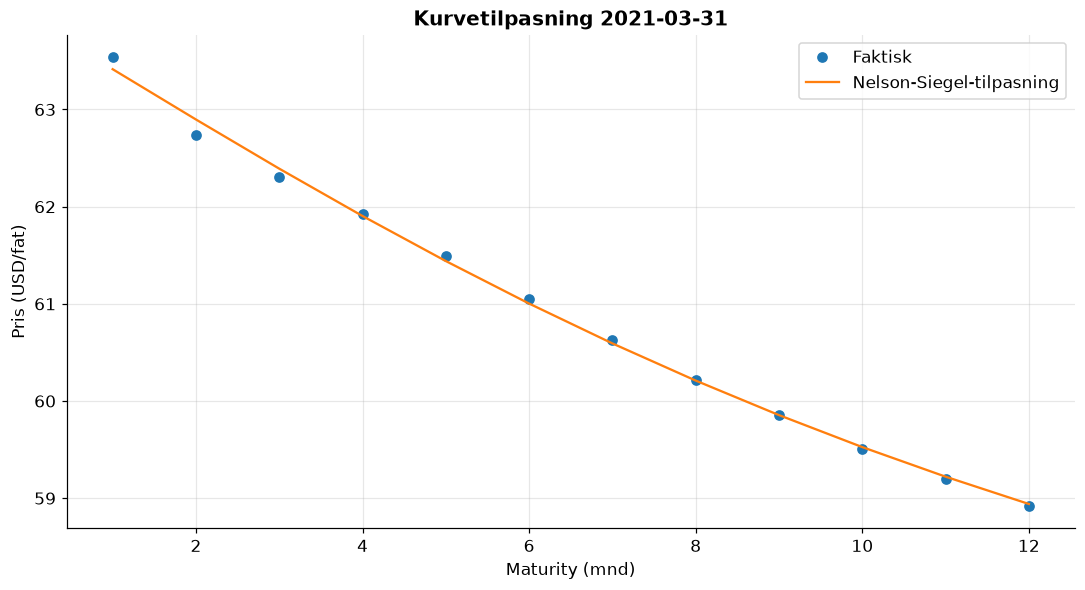

,Level,Slope,Curvature
date,,,
2001-01-31,21.154169,5.707558,1.509750
2001-02-28,18.663796,6.653857,9.921115
2001-03-31,19.274442,5.252150,8.076571
2001-04-30,19.972224,8.036444,7.167707
2001-05-31,21.810950,7.899744,1.241018


In [4]:
from src import diebold_li
factors = diebold_li.run()
show("03_factor_loadings.png", "03_dl_factors.png", "03_sample_fit.png")
factors.head()

## Steg 4 – Rullende out-of-sample prognoser

Vi forutsier NOK/USD én måned fram ved å modellere **endringen** $\Delta y_{t+1}$
fra informasjon kjent på tid $t$, og setter nivåprognosen = $y_t + \widehat{\Delta y}$.

På hvert steg trenes modellen kun på fortiden (utvidende vindu), så predikeres
neste måned – ingen lekkasje. Modeller: enkel/multippel regresjon, AR(1),
Elastic Net, en PyTorch-LSTM, og en invers-MSE-kombinasjon. Benchmarks: random
walk med og uten drift.

*(LSTM-en trenes på nytt hvert steg; cellen tar ~30 sekunder.)*

In [5]:
from src import forecasting
pred = forecasting.run_rolling(verbose=False)
pred[["y_true", "Multiple", "Combination", "LSTM", "RW"]].head()

[fc] 181 OOS-prognoser lagret til C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\forecasts.parquet


,y_true,Multiple,Combination,LSTM,RW
date,,,,,
2006-03-31,0.152613,0.147542,0.148517,0.149234,0.148260
2006-04-30,0.162562,0.152713,0.152961,0.152457,0.152613
2006-05-31,0.164382,0.163889,0.165668,0.173911,0.162562
2006-06-30,0.160730,0.165213,0.166370,0.170735,0.164382
2006-07-31,0.162324,0.161100,0.160673,0.157852,0.160730


## Steg 5 – Evaluering

RMSE mot random walk, CSSED over tid, og Diebold-Mariano-test for å avgjøre om
forskjellene er statistisk signifikante.

In [6]:
from src import evaluation
ev = evaluation.load_forecasts()
rmse = evaluation.rmse_table(ev)
rmse

[eval] RMSE-tabell:
       model     RMSE  RMSE_rel_RW
Combination 0.005224     0.999572
         RW 0.005226     1.000000
   Multiple 0.005255     1.005615
   RW_drift 0.005260     1.006474
 ElasticNet 0.005279     1.010154
         AR 0.005306     1.015236
     Linear 0.005315     1.017092
       LSTM 0.006318     1.208866


,model,RMSE,RMSE_rel_RW
5,Combination,0.005224,0.999572
6,RW,0.005226,1.000000
1,Multiple,0.005255,1.005615
7,RW_drift,0.005260,1.006474
3,ElasticNet,0.005279,1.010154
2,AR,0.005306,1.015236
0,Linear,0.005315,1.017092
4,LSTM,0.006318,1.208866


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_pred_vs_true.png
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_cssed.png


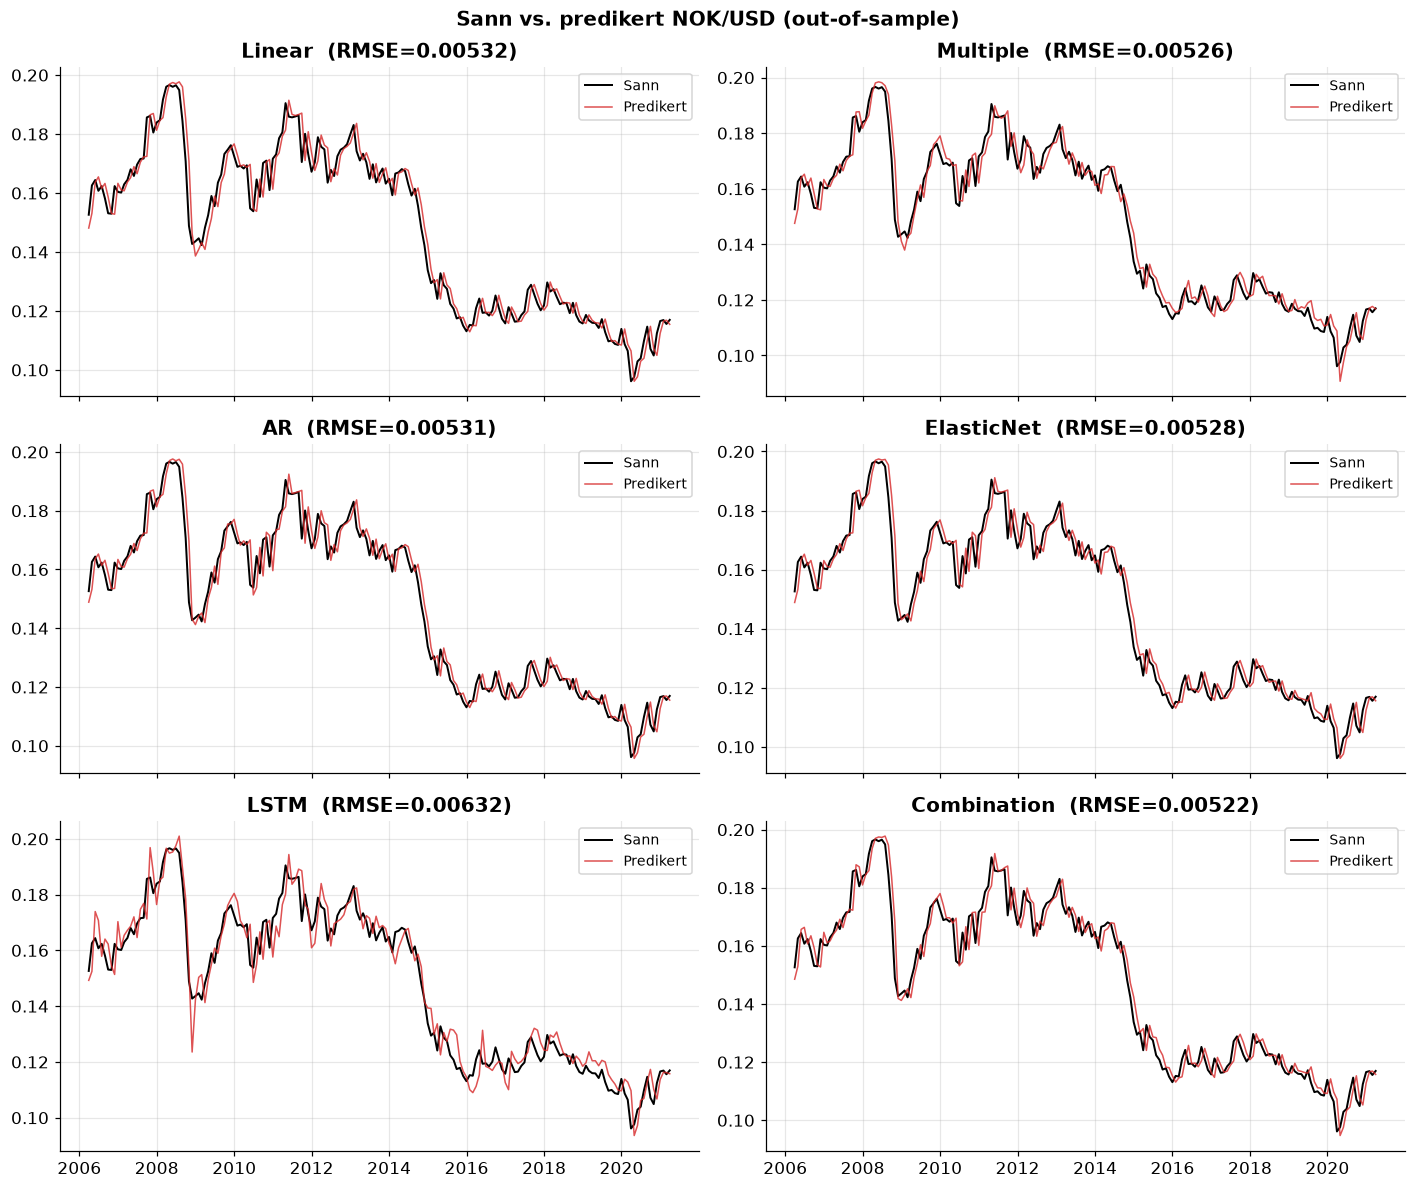

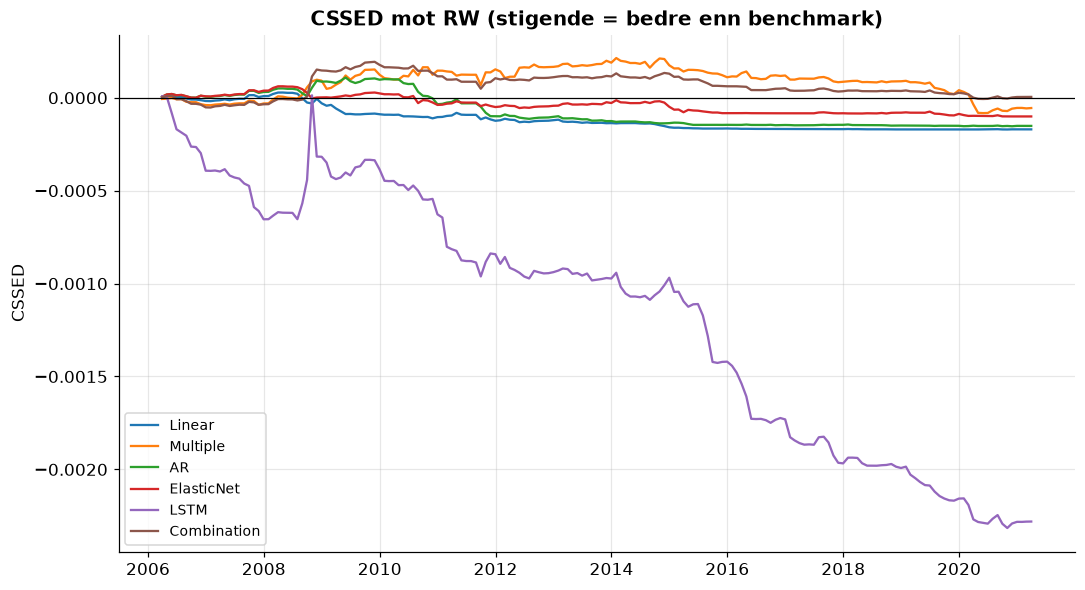

In [7]:
evaluation.plot_pred_vs_true(ev)
evaluation.cssed(ev)
show("05_pred_vs_true.png", "05_cssed.png")

In [8]:
dm = evaluation.dm_pvalue_matrix(ev)
dm.round(3)

[eval] DM p-verdier (rad vs kolonne):
              Linear  Multiple     AR  ElasticNet   LSTM  Combination     RW  RW_drift
Linear          NaN     0.621  0.868       0.459  0.007        0.295  0.034     0.107
Multiple      0.621       NaN  0.699       0.829  0.002        0.736  0.800     0.970
AR            0.868     0.699    NaN       0.684  0.005        0.269  0.196     0.471
ElasticNet    0.459     0.829  0.684         NaN  0.005        0.539  0.284     0.607
LSTM          0.007     0.002  0.005       0.005    NaN        0.001  0.003     0.005
Combination   0.295     0.736  0.269       0.539  0.001          NaN  0.979     0.706
RW            0.034     0.800  0.196       0.284  0.003        0.979    NaN     0.374
RW_drift      0.107     0.970  0.471       0.607  0.005        0.706  0.374       NaN
[eval] DM vs RW (negativ stat = bedre enn RW):
       model  DM_stat_vs_RW  p_value_vs_RW
     Linear         2.1395         0.0337
   Multiple         0.2540         0.7998
         AR  

,Linear,Multiple,AR,ElasticNet,LSTM,Combination,RW,RW_drift
Linear,NaN,0.621,0.868,0.459,0.007,0.295,0.034,0.107
Multiple,0.621,NaN,0.699,0.829,0.002,0.736,0.800,0.970
AR,0.868,0.699,NaN,0.684,0.005,0.269,0.196,0.471
ElasticNet,0.459,0.829,0.684,NaN,0.005,0.539,0.284,0.607
LSTM,0.007,0.002,0.005,0.005,NaN,0.001,0.003,0.005
Combination,0.295,0.736,0.269,0.539,0.001,NaN,0.979,0.706
RW,0.034,0.800,0.196,0.284,0.003,0.979,NaN,0.374
RW_drift,0.107,0.970,0.471,0.607,0.005,0.706,0.374,NaN


**Funn:** Kombinasjonen er så vidt foran random walk, men ingen modell slår RW
*signifikant* (DM). LSTM og enkel lineær er signifikant dårligere. Dette er i tråd
med Meese–Rogoff: valuta er svært vanskelig å slå med en random walk.

## Steg 6 – Lønnsomhet

En enkel fortegnsstrategi: long/short kronen ut fra predikert retning. Poenget –
lav RMSE og lønnsom *retning* er ikke det samme.

[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\06_cumulative_returns.png
[trade] Strategistatistikk:
              total_return  ann_return  ann_vol  sharpe  hit_rate
Multiple            1.051       0.055    0.119   0.459     0.541
Combination         0.286       0.024    0.120   0.198     0.519
LSTM               -0.004       0.007    0.120   0.057     0.503
ElasticNet         -0.071       0.002    0.120   0.020     0.525
BuyHold            -0.211      -0.008    0.120  -0.071       NaN
AR                 -0.340      -0.020    0.120  -0.170     0.503
Linear             -0.628      -0.058    0.119  -0.490     0.492


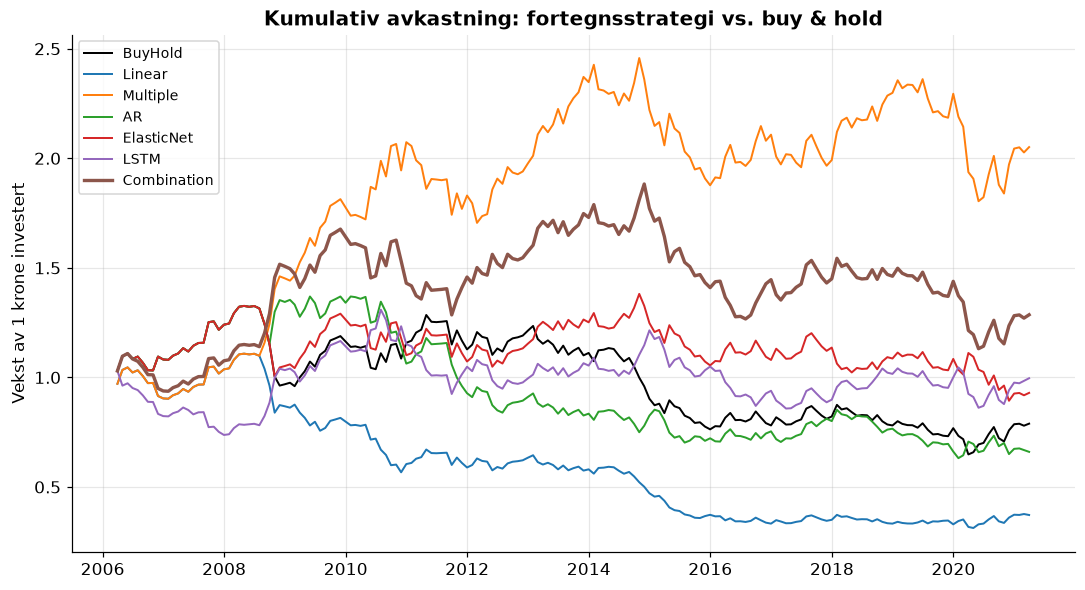

,total_return,ann_return,ann_vol,sharpe,hit_rate
Multiple,1.051,0.055,0.119,0.459,0.541
Combination,0.286,0.024,0.120,0.198,0.519
LSTM,-0.004,0.007,0.120,0.057,0.503
ElasticNet,-0.071,0.002,0.120,0.020,0.525
BuyHold,-0.211,-0.008,0.120,-0.071,NaN
AR,-0.340,-0.020,0.120,-0.170,0.503
Linear,-0.628,-0.058,0.119,-0.490,0.492


In [9]:
from src import trading
stats = trading.run()
show("06_cumulative_returns.png")
stats.round(3)

## Konklusjon

Terminstruktur-faktorene bærer et **svakt, men økonomisk meningsfullt
retningssignal** for kronen. De slår ikke random walk på ren prognosepresisjon (i
tråd med litteraturen), men en retningsbasert strategi på multippel regresjon ga
likevel klart bedre avkastning enn buy & hold. Resultatene er bevisst rapportert
uten overdrivelse.